<a href="https://colab.research.google.com/github/Durucill/DSA210-Spring2026-Project/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

         Date  Order_Day  Snack_Available  Netflix_Count
0  2026-02-15          0                0            0.0
1  2026-02-16          0                0            0.0
2  2026-02-17          0                0            0.0
3  2026-02-18          0                0            0.0
4  2026-02-19          0                0            0.0
       Order_Day  Snack_Available  Netflix_Count
count  60.000000        60.000000      60.000000
mean    0.083333         0.283333       0.550000
std     0.278718         0.454420       1.701694
min     0.000000         0.000000       0.000000
25%     0.000000         0.000000       0.000000
50%     0.000000         0.000000       0.000000
75%     0.000000         1.000000       0.000000
max     1.000000         1.000000      10.000000


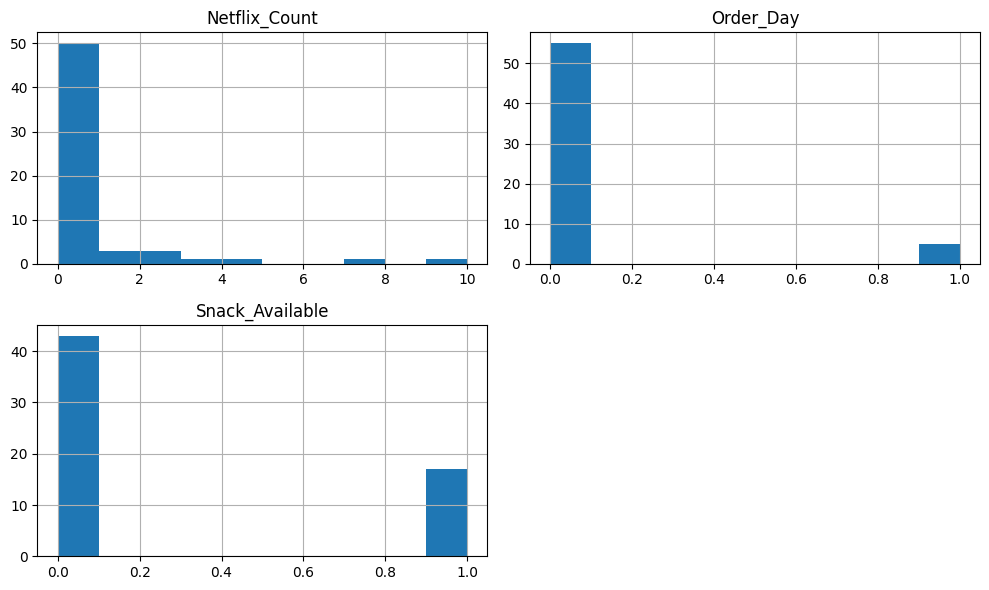

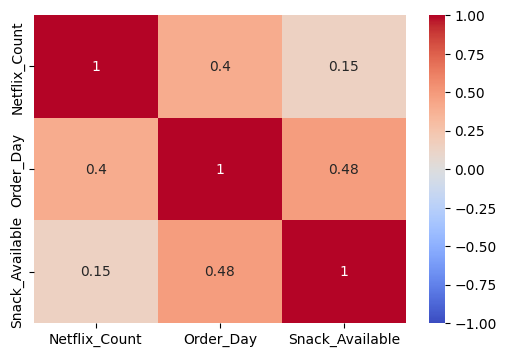

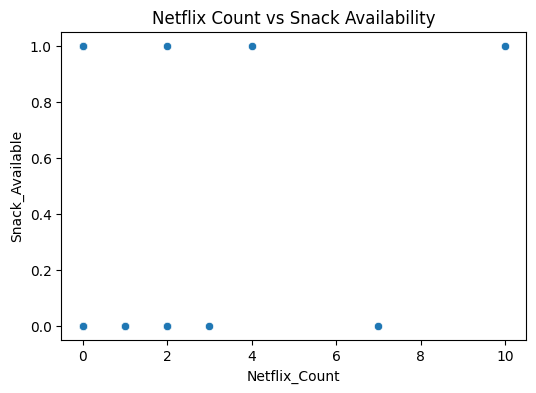

Correlation: 0.14575756030320447
P-value: 0.26646936058195386
Snack_Available
0    0.395349
1    0.941176
Name: Netflix_Count, dtype: float64
Saved: final_merged_analysis_data.csv


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

food = pd.read_csv("food.csv", sep=";", encoding="utf-8-sig")
netflix = pd.read_csv("netflix.csv", sep=";", encoding="utf-8-sig")

food.columns = [c.replace("\ufeff", "").strip() for c in food.columns]
netflix.columns = [c.replace("\ufeff", "").strip() for c in netflix.columns]

food = food[["Date", "Netflix_Count", "Order_Day", "Snack_Available"]]

netflix = netflix.iloc[:, [0, -1]]
netflix.columns = ["Title", "Date"]

food["Date"] = pd.to_datetime(food["Date"], errors="coerce")
netflix["Date"] = pd.to_datetime(netflix["Date"], errors="coerce")

food = food.dropna(subset=["Date"])
netflix = netflix.dropna(subset=["Date"])

food["Date"] = food["Date"].dt.strftime("%Y-%m-%d")
netflix["Date"] = netflix["Date"].dt.strftime("%Y-%m-%d")

daily_netflix = netflix.groupby("Date").size().reset_index(name="Netflix_Count_Real")

df = food.merge(daily_netflix, on="Date", how="left")
df["Netflix_Count_Real"] = df["Netflix_Count_Real"].fillna(0)

df = df.drop(columns=["Netflix_Count"])
df = df.rename(columns={"Netflix_Count_Real": "Netflix_Count"})

df["Netflix_Count"] = pd.to_numeric(df["Netflix_Count"], errors="coerce").fillna(0)
df["Order_Day"] = pd.to_numeric(df["Order_Day"], errors="coerce").fillna(0)
df["Snack_Available"] = pd.to_numeric(df["Snack_Available"], errors="coerce").fillna(0)

print(df.head())
print(df.describe())

df[["Netflix_Count", "Order_Day", "Snack_Available"]].hist(figsize=(10,6))
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df[["Netflix_Count", "Order_Day", "Snack_Available"]].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="Netflix_Count", y="Snack_Available", data=df)
plt.title("Netflix Count vs Snack Availability")
plt.show()

corr, p_value = pearsonr(df["Netflix_Count"], df["Snack_Available"])

print("Correlation:", corr)
print("P-value:", p_value)

print(df.groupby("Snack_Available")["Netflix_Count"].mean())

df.to_csv("final_merged_analysis_data.csv", index=False)
print("Saved: final_merged_analysis_data.csv")